In [1]:
import numpy as np
import pandas as pd
import matplotlib as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing


Dicccionario:
Var 1=

In [2]:
housing = fetch_california_housing()
housing

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': '.. _california_housing_dataset:\n

In [3]:
X = pd.DataFrame(housing.data, columns=housing.feature_names)
Y = pd.DataFrame(housing.target, columns=['MedHouseVal'])

housing_data =pd.concat([X,Y], axis=1)

In [4]:
housing_data.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [5]:
housing_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [6]:
housing_data.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [7]:
print(housing_data.isnull().sum())

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


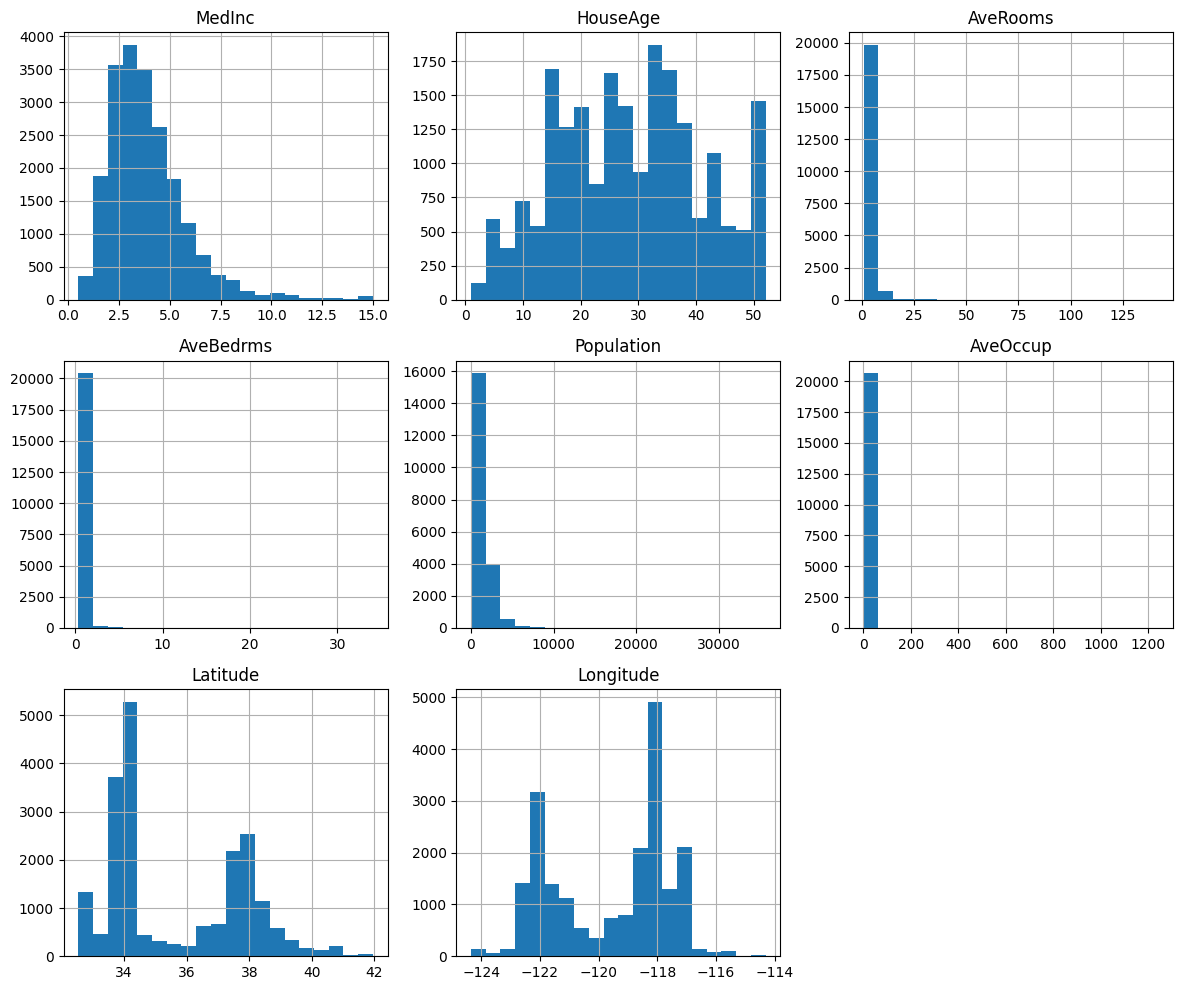

In [8]:
import matplotlib.pyplot as plt

X.hist(bins=20, figsize=(12,10))
plt.tight_layout()
plt.show()

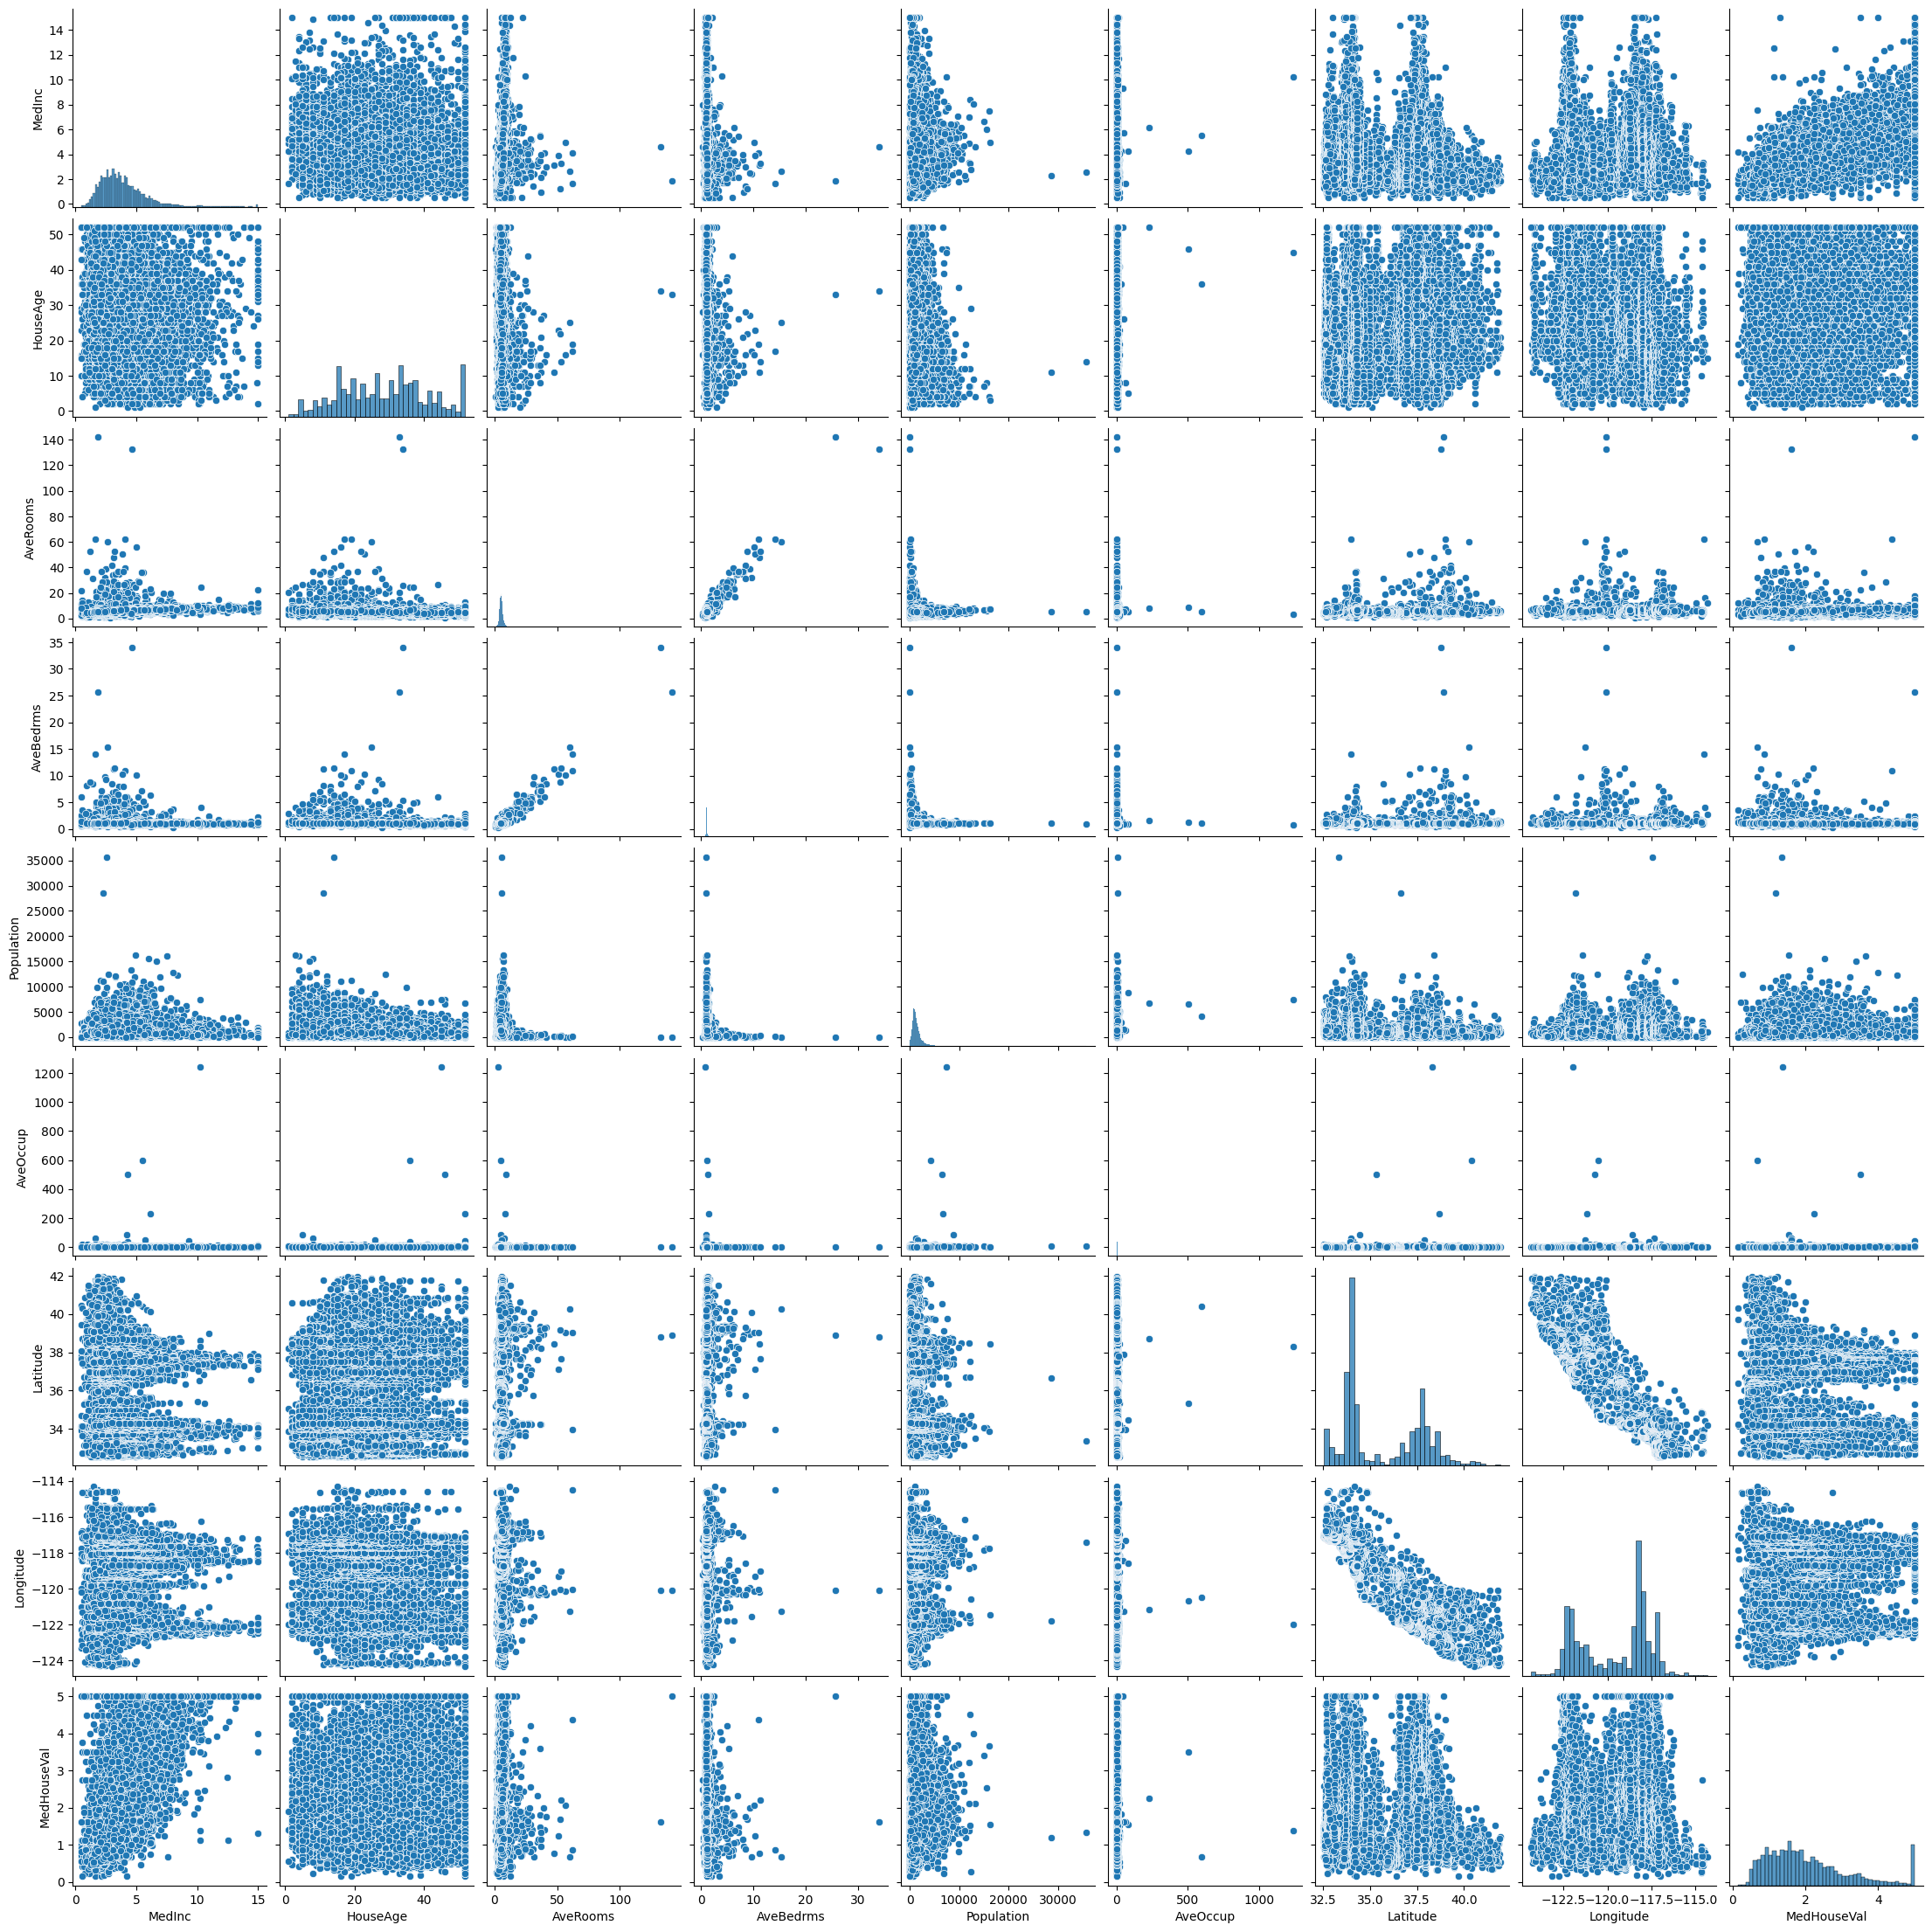

In [9]:
sns.pairplot(housing_data)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

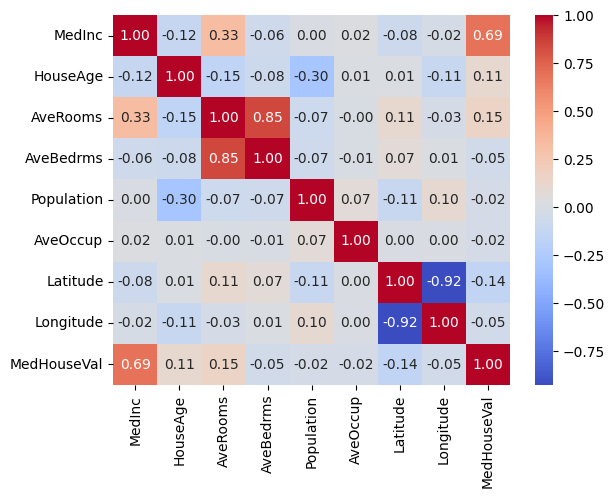

In [10]:
sns.heatmap(housing_data.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.show

<Axes: xlabel='Longitude', ylabel='Latitude'>

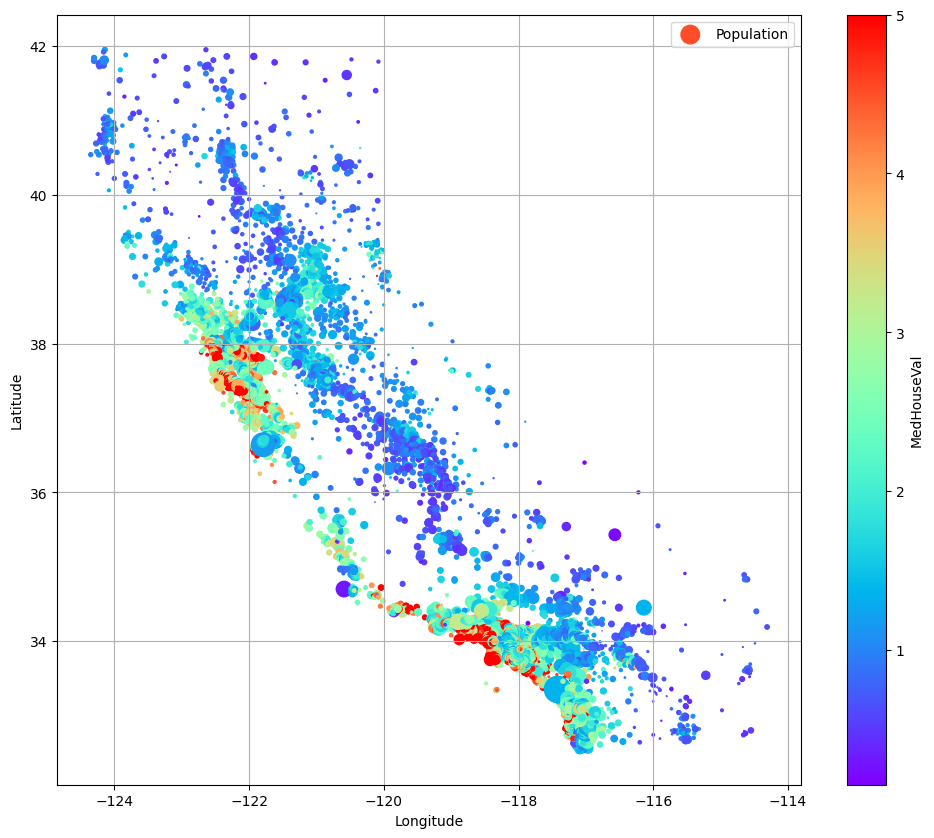

In [11]:
housing_data.plot(kind="scatter", x="Longitude", y="Latitude", grid=True,
                  s=housing_data['Population']/100, label="Population",
                  c="MedHouseVal", cmap="rainbow", colorbar=True,
                  legend=True, sharex=False, figsize=(12, 10)
                  )

In [12]:
from sklearn.cluster import KMeans

n_clusters = 7

Kmeans=KMeans(n_clusters=n_clusters, random_state=42)

X['Cluster']=Kmeans.fit_predict(X[['Longitude','Latitude']])


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


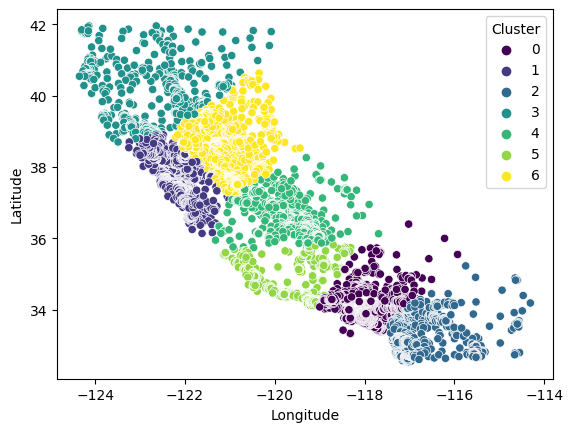

In [13]:
sns.scatterplot(x=X['Longitude'], y=X['Latitude'], hue=X['Cluster'], palette='viridis')
plt.show()

VIF= mide multicolinealidad, la cual es peligrosa para los modelos de regresiòn lineal.

un VIF > 5 se considera peligroso, y se recomienda eliminar las variables con VIF > 10.


In [14]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data=pd.DataFrame()
vif_data["Variable"]=X.columns
vif_data ["VIF"]=[variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
print(vif_data)

     Variable         VIF
0      MedInc   12.622775
1    HouseAge    7.604330
2    AveRooms   47.979088
3   AveBedrms   45.016971
4  Population    2.959789
5    AveOccup    1.095812
6    Latitude  728.886265
7   Longitude  743.650420
8     Cluster    2.735598


In [15]:
X= X.drop(columns=['Latitude','Longitude'])


In [16]:
X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Cluster
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,1
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,1
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,1
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,1
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,1
...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,6
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,6
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,6
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,6


In [17]:
vif_data=pd.DataFrame()
vif_data["Variable"]=X.columns
vif_data ["VIF"]=[variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
print(vif_data)

     Variable        VIF
0      MedInc   7.959095
1    HouseAge   4.349689
2    AveRooms  42.436844
3   AveBedrms  34.184372
4  Population   2.339937
5    AveOccup   1.095705
6     Cluster   1.637265


In [18]:
X= X.drop(columns=['AveBedrms'])

In [19]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   Population  20640 non-null  float64
 4   AveOccup    20640 non-null  float64
 5   Cluster     20640 non-null  int32  
dtypes: float64(5), int32(1)
memory usage: 887.0 KB


In [20]:
vif_data=pd.DataFrame()
vif_data["Variable"]=X.columns
vif_data ["VIF"]=[variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
print(vif_data)

     Variable       VIF
0      MedInc  5.245472
1    HouseAge  3.300159
2    AveRooms  5.922953
3  Population  2.149232
4    AveOccup  1.095421
5     Cluster  1.634098


In [21]:
housing_data =pd.concat([X,Y], axis=1)

In [22]:
housing_data.head()

,MedInc,HouseAge,AveRooms,Population,AveOccup,Cluster,MedHouseVal
0,8.3252,41.0,6.984127,322.0,2.555556,1,4.526
1,8.3014,21.0,6.238137,2401.0,2.109842,1,3.585
2,7.2574,52.0,8.288136,496.0,2.802260,1,3.521
3,5.6431,52.0,5.817352,558.0,2.547945,1,3.413
4,3.8462,52.0,6.281853,565.0,2.181467,1,3.422


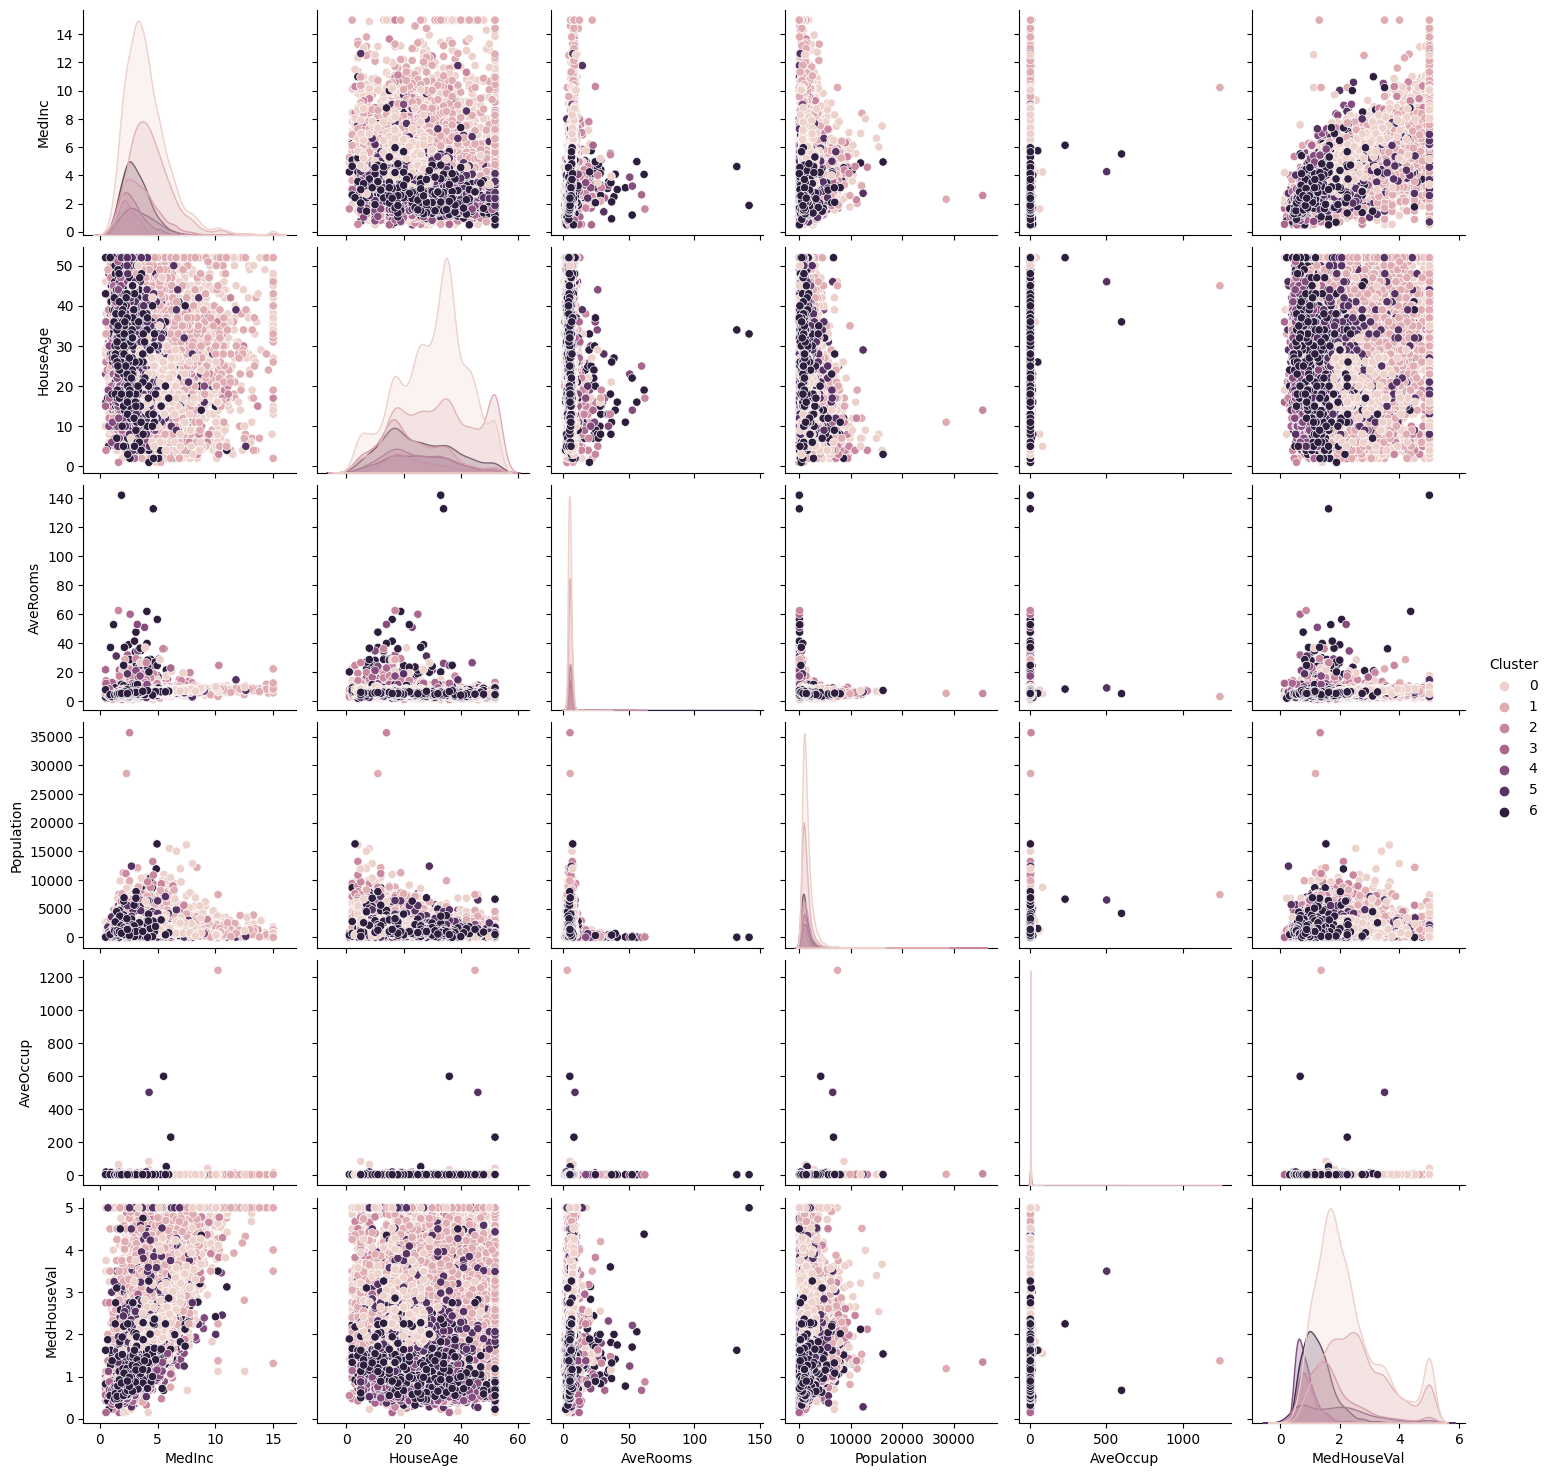

In [23]:
sns.pairplot(housing_data, hue='Cluster')
plt.show()

In [24]:
housing_data

,MedInc,HouseAge,AveRooms,Population,AveOccup,Cluster,MedHouseVal
0,8.3252,41.0,6.984127,322.0,2.555556,1,4.526
1,8.3014,21.0,6.238137,2401.0,2.109842,1,3.585
2,7.2574,52.0,8.288136,496.0,2.802260,1,3.521
3,5.6431,52.0,5.817352,558.0,2.547945,1,3.413
4,3.8462,52.0,6.281853,565.0,2.181467,1,3.422
...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,845.0,2.560606,6,0.781
20636,2.5568,18.0,6.114035,356.0,3.122807,6,0.771
20637,1.7000,17.0,5.205543,1007.0,2.325635,6,0.923
20638,1.8672,18.0,5.329513,741.0,2.123209,6,0.847


In [25]:
import statsmodels.formula.api as smf

todas_columnas= '+'.join(housing_data.columns[:-1])
formula = 'MedHouseVal ~' + todas_columnas + ' + '

from itertools import combinations
inter_numerico= [f"{col1}:{col2}" for col1, col2 in combinations(housing_data.columns[:-1],2)]
formula += ' + ' + '+ '.join(inter_numerico)

inter_categorico= [f"C(Cluster):{col}" for col in housing_data.columns[:-1] if col !='Cluster']
formula += ' + ' + '+ '.join(inter_categorico)

model=smf.ols(formula=formula, data=housing_data).fit()

print(model.summary())




                            OLS Regression Results                            
Dep. Variable:            MedHouseVal   R-squared:                       0.624
Model:                            OLS   Adj. R-squared:                  0.623
Method:                 Least Squares   F-statistic:                     742.9
Date:                Tue, 21 Nov 2023   Prob (F-statistic):               0.00
Time:                        20:48:14   Log-Likelihood:                -22148.
No. Observations:               20640   AIC:                         4.439e+04
Df Residuals:                   20593   BIC:                         4.476e+04
Df Model:                          46                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

MedInc:AveRooms! candidata a ser eliminada.

In [26]:

# base code
import statsmodels
import statsmodels.formula.api as smf
import pandas as pd
import numpy as np
import seaborn as sns
from statsmodels.tools.tools import maybe_unwrap_results
from statsmodels.graphics.gofplots import ProbPlot
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
from typing import Type

style_talk = 'seaborn-talk'    #refer to plt.style.available

class LinearRegDiagnostic():
    """
    Diagnostic plots to identify potential problems in a linear regression fit.
    Mainly,
        a. non-linearity of data
        b. Correlation of error terms
        c. non-constant variance
        d. outliers
        e. high-leverage points
        f. collinearity

    Authors:
        Prajwal Kafle (p33ajkafle@gmail.com, where 3 = r)
        Does not come with any sort of warranty.
        Please test the code one your end before using.

        Matt Spinelli (m3spinelli@gmail.com, where 3 = r)
        (1) Fixed incorrect annotation of the top most extreme residuals in
            the Residuals vs Fitted and, especially, the Normal Q-Q plots.
        (2) Changed Residuals vs Leverage plot to match closer the y-axis
            range shown in the equivalent plot in the R package ggfortify.
        (3) Added horizontal line at y=0 in Residuals vs Leverage plot to
            match the plots in R package ggfortify and base R.
        (4) Added option for placing a vertical guideline on the Residuals
            vs Leverage plot using the rule of thumb of h = 2p/n to denote
            high leverage (high_leverage_threshold=True).
        (5) Added two more ways to compute the Cook's Distance (D) threshold:
            * 'baseR': D > 1 and D > 0.5 (default)
            * 'convention': D > 4/n
            * 'dof': D > 4 / (n - k - 1)
        (6) Fixed class name to conform to Pascal casing convention
        (7) Fixed Residuals vs Leverage legend to work with loc='best'
    """

    def __init__(self,
                 results: Type[statsmodels.regression.linear_model.RegressionResultsWrapper]) -> None:
        """
        For a linear regression model, generates following diagnostic plots:

        a. residual
        b. qq
        c. scale location and
        d. leverage

        and a table

        e. vif

        Args:
            results (Type[statsmodels.regression.linear_model.RegressionResultsWrapper]):
                must be instance of statsmodels.regression.linear_model object

        Raises:
            TypeError: if instance does not belong to above object

        Example:
        >>> import numpy as np
        >>> import pandas as pd
        >>> import statsmodels.formula.api as smf
        >>> x = np.linspace(-np.pi, np.pi, 100)
        >>> y = 3*x + 8 + np.random.normal(0,1, 100)
        >>> df = pd.DataFrame({'x':x, 'y':y})
        >>> res = smf.ols(formula= "y ~ x", data=df).fit()
        >>> cls = Linear_Reg_Diagnostic(res)
        >>> cls(plot_context="seaborn-paper")

        In case you do not need all plots you can also independently make an individual plot/table
        in following ways

        >>> cls = Linear_Reg_Diagnostic(res)
        >>> cls.residual_plot()
        >>> cls.qq_plot()
        >>> cls.scale_location_plot()
        >>> cls.leverage_plot()
        >>> cls.vif_table()
        """

        if isinstance(results, statsmodels.regression.linear_model.RegressionResultsWrapper) is False:
            raise TypeError("result must be instance of statsmodels.regression.linear_model.RegressionResultsWrapper object")

        self.results = maybe_unwrap_results(results)

        self.y_true = self.results.model.endog
        self.y_predict = self.results.fittedvalues
        self.xvar = self.results.model.exog
        self.xvar_names = self.results.model.exog_names

        self.residual = np.array(self.results.resid)
        influence = self.results.get_influence()
        self.residual_norm = influence.resid_studentized_internal
        self.leverage = influence.hat_matrix_diag
        self.cooks_distance = influence.cooks_distance[0]
        self.nparams = len(self.results.params)
        self.nresids = len(self.residual_norm)

    def __call__(self, plot_context='seaborn-paper', **kwargs):
        # print(plt.style.available)
        with plt.style.context(plot_context):
            fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10,10))
            self.residual_plot(ax=ax[0,0])
            self.qq_plot(ax=ax[0,1])
            self.scale_location_plot(ax=ax[1,0])
            self.leverage_plot(
                ax=ax[1,1],
                high_leverage_threshold = kwargs.get('high_leverage_threshold'),
                cooks_threshold = kwargs.get('cooks_threshold'))
            plt.show()

        return self.vif_table(), fig, ax,

    def residual_plot(self, ax=None):
        """
        Residual vs Fitted Plot

        Graphical tool to identify non-linearity.
        (Roughly) Horizontal red line is an indicator that the residual has a linear pattern
        """
        if ax is None:
            fig, ax = plt.subplots()

        sns.residplot(
            x=self.y_predict,
            y=self.residual,
            lowess=True,
            scatter_kws={'alpha': 0.5},
            line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8},
            ax=ax)

        # annotations
        residual_abs = np.abs(self.residual)
        abs_resid = np.flip(np.argsort(residual_abs), 0)
        abs_resid_top_3 = abs_resid[:3]
        for i in abs_resid_top_3:
            ax.annotate(
                i,
                xy=(self.y_predict[i], self.residual[i]),
                color='C3')

        ax.set_title('Residuals vs Fitted', fontweight="bold")
        ax.set_xlabel('Fitted values')
        ax.set_ylabel('Residuals')
        return ax

    def qq_plot(self, ax=None):
        """
        Standarized Residual vs Theoretical Quantile plot

        Used to visually check if residuals are normally distributed.
        Points spread along the diagonal line will suggest so.
        """
        if ax is None:
            fig, ax = plt.subplots()

        QQ = ProbPlot(self.residual_norm)
        fig = QQ.qqplot(line='45', alpha=0.5, lw=1, ax=ax)

        # annotations
        abs_norm_resid = np.flip(np.argsort(np.abs(self.residual_norm)), 0)
        abs_norm_resid_top_3 = abs_norm_resid[:3]
        for i, x, y in self.__qq_top_resid(QQ.theoretical_quantiles, abs_norm_resid_top_3):
            ax.annotate(
                i,
                xy=(x, y),
                ha='right',
                color='C3')

        ax.set_title('Normal Q-Q', fontweight="bold")
        ax.set_xlabel('Theoretical Quantiles')
        ax.set_ylabel('Standardized Residuals')
        return ax

    def scale_location_plot(self, ax=None):
        """
        Sqrt(Standarized Residual) vs Fitted values plot

        Used to check homoscedasticity of the residuals.
        Horizontal line will suggest so.
        """
        if ax is None:
            fig, ax = plt.subplots()

        residual_norm_abs_sqrt = np.sqrt(np.abs(self.residual_norm))

        ax.scatter(self.y_predict, residual_norm_abs_sqrt, alpha=0.5);
        sns.regplot(
            x=self.y_predict,
            y=residual_norm_abs_sqrt,
            scatter=False, ci=False,
            lowess=True,
            line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8},
            ax=ax)

        # annotations
        abs_sq_norm_resid = np.flip(np.argsort(residual_norm_abs_sqrt), 0)
        abs_sq_norm_resid_top_3 = abs_sq_norm_resid[:3]
        for i in abs_sq_norm_resid_top_3:
            ax.annotate(
                i,
                xy=(self.y_predict[i], residual_norm_abs_sqrt[i]),
                color='C3')

        ax.set_title('Scale-Location', fontweight="bold")
        ax.set_xlabel('Fitted values')
        ax.set_ylabel(r'$\sqrt{|\mathrm{Standardized\ Residuals}|}$');
        return ax

    def leverage_plot(self, ax=None, high_leverage_threshold=False, cooks_threshold='convention'):
        """
        Residual vs Leverage plot

        Points falling outside Cook's distance curves are considered observation that can sway the fit
        aka are influential.
        Good to have none outside the curves.
        """
        if ax is None:
            fig, ax = plt.subplots()

        ax.scatter(
            self.leverage,
            self.residual_norm,
            alpha=0.5);

        sns.regplot(
            x=self.leverage,
            y=self.residual_norm,
            scatter=False,
            ci=False,
            lowess=True,
            line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8},
            ax=ax)

        # annotations
        leverage_top_3 = np.flip(np.argsort(self.cooks_distance), 0)[:3]
        for i in leverage_top_3:
            ax.annotate(
                i,
                xy=(self.leverage[i], self.residual_norm[i]),
                color = 'C3')

        factors = []
        if cooks_threshold == 'baseR' or cooks_threshold is None:
            factors = [1, 0.5]
        elif cooks_threshold == 'convention':
            factors = [4/self.nresids]
        elif cooks_threshold == 'dof':
            factors = [4/ (self.nresids - self.nparams)]
        else:
            raise ValueError("threshold_method must be one of the following: 'convention', 'dof', or 'baseR' (default)")
        for i, factor in enumerate(factors):
            label = "Cook's distance" if i == 0 else None
            xtemp, ytemp = self.__cooks_dist_line(factor)
            ax.plot(xtemp, ytemp, label=label, lw=1.25, ls='--', color='red')
            ax.plot(xtemp, np.negative(ytemp), lw=1.25, ls='--', color='red')

        if high_leverage_threshold:
            high_leverage = 2 * self.nparams / self.nresids
            if max(self.leverage) > high_leverage:
                ax.axvline(high_leverage, label='High leverage', ls='-.', color='purple', lw=1)

        ax.axhline(0, ls='dotted', color='black', lw=1.25)
        ax.set_xlim(0, max(self.leverage)+0.01)
        ax.set_ylim(min(self.residual_norm)-0.1, max(self.residual_norm)+0.1)
        ax.set_title('Residuals vs Leverage', fontweight="bold")
        ax.set_xlabel('Leverage')
        ax.set_ylabel('Standardized Residuals')
        plt.legend(loc='best')
        return ax

    def vif_table(self):
        """
        VIF table

        VIF, the variance inflation factor, is a measure of multicollinearity.
        VIF > 5 for a variable indicates that it is highly collinear with the
        other input variables.
        """
        vif_df = pd.DataFrame()
        vif_df["Features"] = self.xvar_names
        vif_df["VIF Factor"] = [variance_inflation_factor(self.xvar, i) for i in range(self.xvar.shape[1])]

        return (vif_df
                .sort_values("VIF Factor")
                .round(2))


    def __cooks_dist_line(self, factor):
        """
        Helper function for plotting Cook's distance curves
        """
        p = self.nparams
        formula = lambda x: np.sqrt((factor * p * (1 - x)) / x)
        x = np.linspace(0.001, max(self.leverage), 50)
        y = formula(x)
        return x, y


    def __qq_top_resid(self, quantiles, top_residual_indices):
        """
        Helper generator function yielding the index and coordinates
        """
        offset = 0
        quant_index = 0
        previous_is_negative = None
        for resid_index in top_residual_indices:
            y = self.residual_norm[resid_index]
            is_negative = y < 0
            if previous_is_negative == None or previous_is_negative == is_negative:
                offset += 1
            else:
                quant_index -= offset
            x = quantiles[quant_index] if is_negative else np.flip(quantiles, 0)[quant_index]
            quant_index += 1
            previous_is_negative = is_negative
            yield resid_index, x, y


Todo esto lo hacemos porque debemos probar los supuestos de la regresión lineal:
Linealidad
Hocedasticidad
Normalidad
Independencia

----
Multicolinealidad
Outliers

In [27]:
Diagnostico_del_modelo= LinearRegDiagnostic(model)

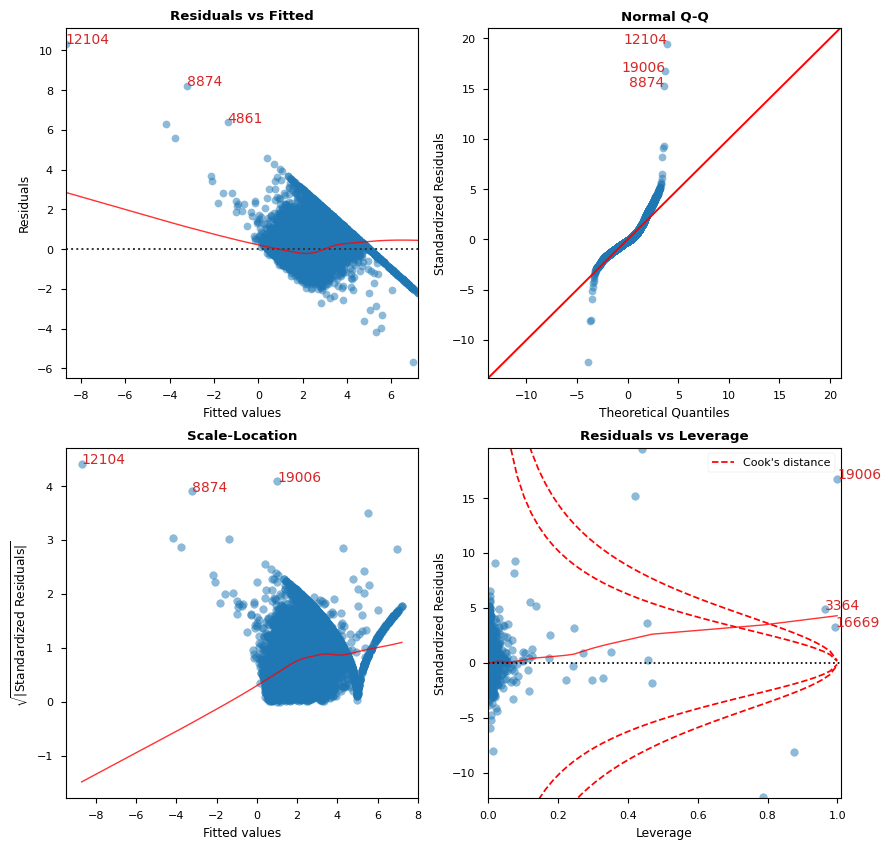

/usr/local/lib/python3.10/dist-packages/statsmodels/stats/outliers_influence.py:198: RuntimeWarning: divide by zero encountered in double_scalars
  vif = 1. / (1. - r_squared_i)


In [28]:
vif, fig, ax =Diagnostico_del_modelo()

<Axes: title={'center': 'Residuals vs Leverage'}, xlabel='Leverage', ylabel='Standardized Residuals'>

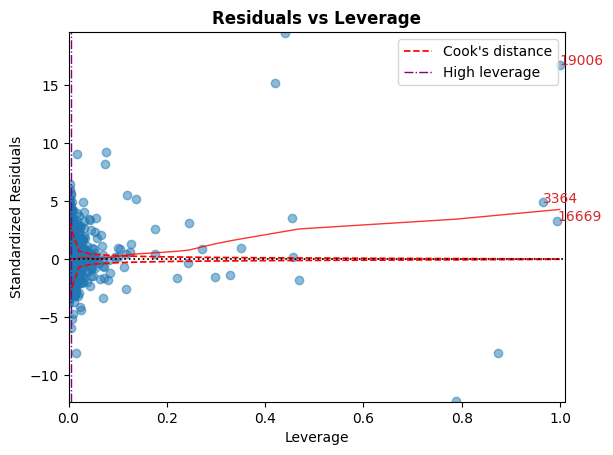

In [29]:
Diagnostico_del_modelo.leverage_plot(high_leverage_threshold=True, cooks_threshold='convention')

In [30]:
cooks_d = model.get_influence().cooks_distance[0]
influential_points = cooks_d > (12 / len(cooks_d))
print(np.sum(influential_points))

235


In [31]:
# Filtering out influential points
housing_filtered_data = housing_data.loc[~influential_points]

In [32]:
todas_columnas= '+'.join(housing_filtered_data.columns[:-1])
formula = 'MedHouseVal ~' + todas_columnas + ' + '

from itertools import combinations
inter_numerico= [f"{col1}:{col2}" for col1, col2 in combinations(housing_filtered_data.columns[:-2],2)]
formula += ' + ' + '+ '.join(inter_numerico)

inter_categorico= [f"C(Cluster):{col}" for col in housing_filtered_data.columns[:-1] if col !='Cluster']
formula += ' + ' + '+ '.join(inter_categorico)

model_2=smf.ols(formula=formula, data=housing_filtered_data).fit()

print(model_2.summary())


                            OLS Regression Results                            
Dep. Variable:            MedHouseVal   R-squared:                       0.683
Model:                            OLS   Adj. R-squared:                  0.683
Method:                 Least Squares   F-statistic:                     955.1
Date:                Tue, 21 Nov 2023   Prob (F-statistic):               0.00
Time:                        20:49:48   Log-Likelihood:                -19850.
No. Observations:               20405   AIC:                         3.979e+04
Df Residuals:                   20358   BIC:                         4.017e+04
Df Model:                          46                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

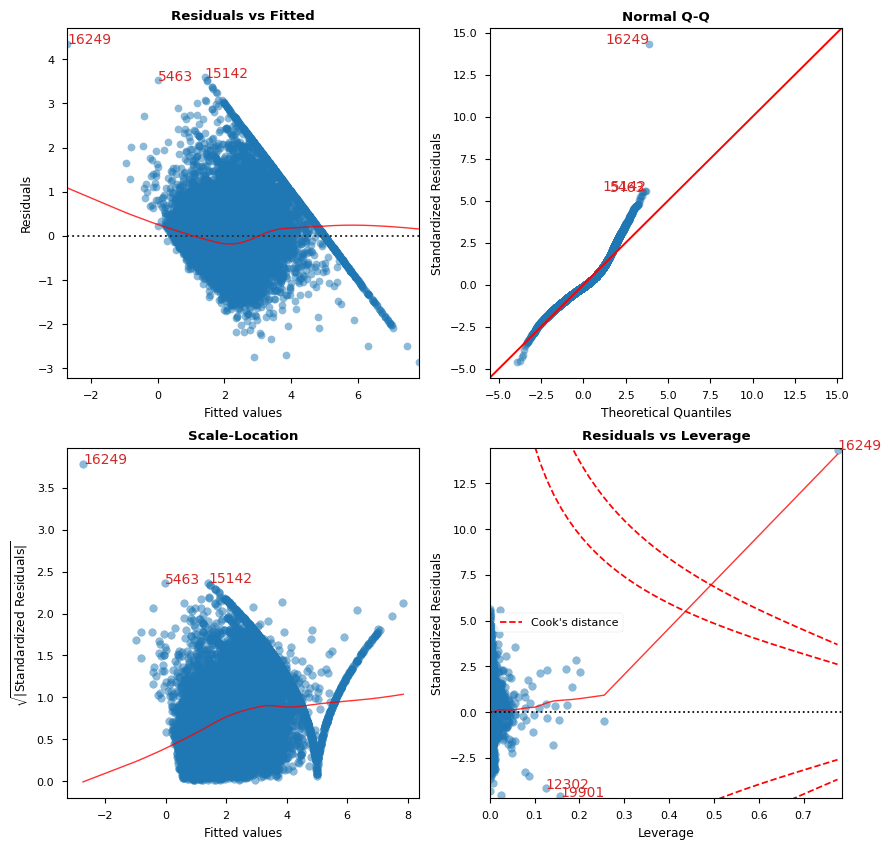

In [33]:
Diag_model_2 = LinearRegDiagnostic(model_2)
vif, fig, ax = Diag_model_2()

Vamos a realizar transformaciones.



In [34]:
housing_transformada = housing_filtered_data.copy()

In [35]:
housing_transformada

,MedInc,HouseAge,AveRooms,Population,AveOccup,Cluster,MedHouseVal
0,8.3252,41.0,6.984127,322.0,2.555556,1,4.526
1,8.3014,21.0,6.238137,2401.0,2.109842,1,3.585
2,7.2574,52.0,8.288136,496.0,2.802260,1,3.521
3,5.6431,52.0,5.817352,558.0,2.547945,1,3.413
4,3.8462,52.0,6.281853,565.0,2.181467,1,3.422
...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,845.0,2.560606,6,0.781
20636,2.5568,18.0,6.114035,356.0,3.122807,6,0.771
20637,1.7000,17.0,5.205543,1007.0,2.325635,6,0.923
20638,1.8672,18.0,5.329513,741.0,2.123209,6,0.847


In [36]:
housing_transformada['MedHouseVal'] = np.log(housing_filtered_data['MedHouseVal']) # las estamos reescribiendo encima de la variable original

housing_transformada['Population'] = np.log(housing_filtered_data['Population'] + 1) # las estamos reescribiendo encima de la variable original

max_age= housing_filtered_data['HouseAge'].max()

housing_transformada['Catagorizacion_HouseAge'] = pd.cut(housing_filtered_data['HouseAge'], bins = [0 ,10 ,20 ,30 ,40 ,50 , max_age + 1], include_lowest= True, labels = False ) # Creando una nueva variable



In [37]:
housing_transformada

,MedInc,HouseAge,AveRooms,Population,AveOccup,Cluster,MedHouseVal,Catagorizacion_HouseAge
0,8.3252,41.0,6.984127,5.777652,2.555556,1,1.509839,4
1,8.3014,21.0,6.238137,7.784057,2.109842,1,1.276758,2
2,7.2574,52.0,8.288136,6.208590,2.802260,1,1.258745,5
3,5.6431,52.0,5.817352,6.326149,2.547945,1,1.227592,5
4,3.8462,52.0,6.281853,6.338594,2.181467,1,1.230225,5
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,6.740519,2.560606,6,-0.247180,2
20636,2.5568,18.0,6.114035,5.877736,3.122807,6,-0.260067,1
20637,1.7000,17.0,5.205543,6.915723,2.325635,6,-0.080126,1
20638,1.8672,18.0,5.329513,6.609349,2.123209,6,-0.166055,1


In [39]:
housing_transformada = housing_transformada.drop(columns =['HouseAge'])


KeyError: ignored

In [40]:
housing_transformada

,MedInc,AveRooms,Population,AveOccup,Cluster,MedHouseVal,Catagorizacion_HouseAge
0,8.3252,6.984127,5.777652,2.555556,1,1.509839,4
1,8.3014,6.238137,7.784057,2.109842,1,1.276758,2
2,7.2574,8.288136,6.208590,2.802260,1,1.258745,5
3,5.6431,5.817352,6.326149,2.547945,1,1.227592,5
4,3.8462,6.281853,6.338594,2.181467,1,1.230225,5
...,...,...,...,...,...,...,...
20635,1.5603,5.045455,6.740519,2.560606,6,-0.247180,2
20636,2.5568,6.114035,5.877736,3.122807,6,-0.260067,1
20637,1.7000,5.205543,6.915723,2.325635,6,-0.080126,1
20638,1.8672,5.329513,6.609349,2.123209,6,-0.166055,1


In [41]:
housing_transformada.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 20405 entries, 0 to 20639
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   MedInc                   20405 non-null  float64
 1   AveRooms                 20405 non-null  float64
 2   Population               20405 non-null  float64
 3   AveOccup                 20405 non-null  float64
 4   Cluster                  20405 non-null  int32  
 5   MedHouseVal              20405 non-null  float64
 6   Catagorizacion_HouseAge  20405 non-null  int64  
dtypes: float64(5), int32(1), int64(1)
memory usage: 1.2 MB


In [42]:
housing_transformada['Catagorizacion_HouseAge'] = housing_transformada['Catagorizacion_HouseAge'].astype('category')

housing_transformada['Cluster'] = housing_transformada['Cluster'].astype('category')

In [43]:
housing_transformada.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 20405 entries, 0 to 20639
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   MedInc                   20405 non-null  float64 
 1   AveRooms                 20405 non-null  float64 
 2   Population               20405 non-null  float64 
 3   AveOccup                 20405 non-null  float64 
 4   Cluster                  20405 non-null  category
 5   MedHouseVal              20405 non-null  float64 
 6   Catagorizacion_HouseAge  20405 non-null  category
dtypes: category(2), float64(5)
memory usage: 996.9 KB


In [45]:
var_predictoras

['MedInc',
 'AveRooms',
 'Population',
 'AveOccup',
 'Cluster',
 'Catagorizacion_HouseAge']

In [46]:
var_predictoras = list(housing_transformada.columns)
var_predictoras.remove('MedHouseVal')

formula1 = 'MedHouseVal ~ ' + ' + '.join(var_predictoras) # modelo de efectos principales


interacion_terminos= [f"{col1}:{col2}" for col1, col2 in combinations(var_predictoras,2)] # efectos interacci'on
formula1 += ' + ' + '+ '.join(interacion_terminos)


model_3 = smf.ols(formula=formula1, data=housing_transformada).fit()

print(model_3.summary())


                            OLS Regression Results                            
Dep. Variable:            MedHouseVal   R-squared:                       0.697
Model:                            OLS   Adj. R-squared:                  0.695
Method:                 Least Squares   F-statistic:                     491.5
Date:                Tue, 21 Nov 2023   Prob (F-statistic):               0.00
Time:                        22:04:15   Log-Likelihood:                -5143.7
No. Observations:               20405   AIC:                         1.048e+04
Df Residuals:                   20309   BIC:                         1.124e+04
Df Model:                          95                                         
Covariance Type:            nonrobust                                         
                                                coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------

Son candidatos a eliminarse las interacciones

1.   AveRooms:AveOccup
2.   Population:AveOccup



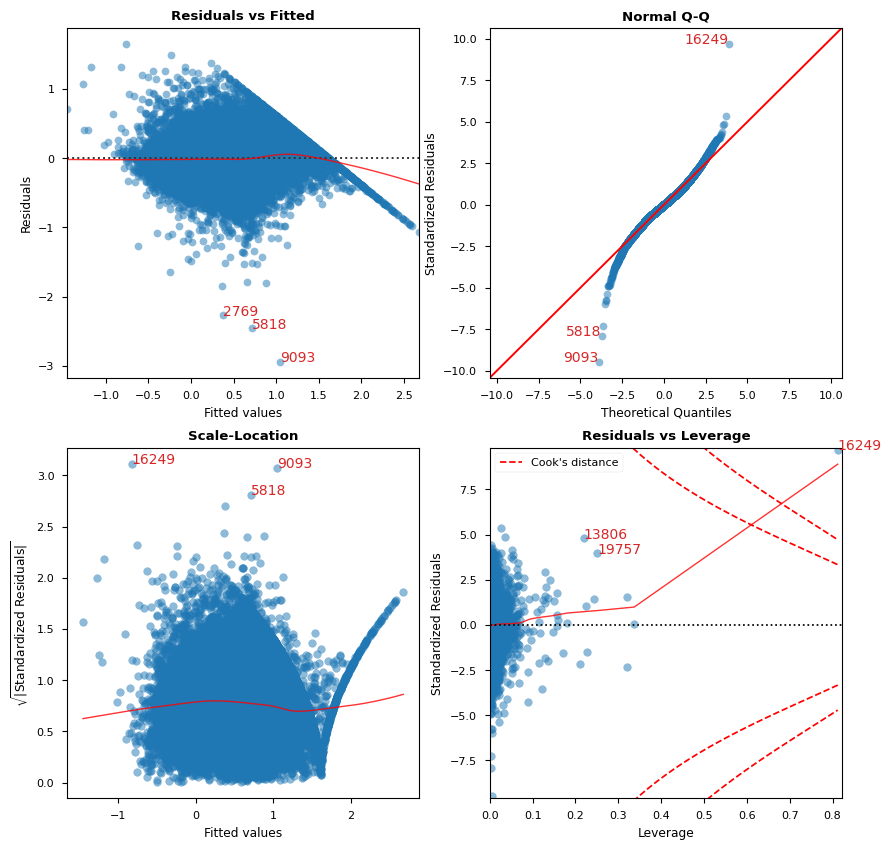

In [47]:
Diag_model_3 = LinearRegDiagnostic(model_3)
vif, fig, ax = Diag_model_3()